In [1]:
import os
import numpy as np
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [2]:
paths = {
    4.0: '../training/runs/sweeps/sigma4.0',
    2.0: '../training/runs/sweeps/sigma2.0',
    1.0: '../training/runs/sweeps/sigma1.0',
    0.5: '../training/runs/sweeps/sigma0.5',
    0.25: '../training/runs/sweeps/sigma0.25',
    0.1: '../training/runs/sweeps/sigma0.1',
}

models = {}
for sigma, path in paths.items():
    model = load_model_from_config(path, dataloaders, device)
    models[sigma] = model

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [9]:
from sensorium.utility.scores import get_correlations

for sigma, model in models.items():
    print(f'{sigma}: {get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)}')

4.0: 0.40723681449890137
2.0: 0.4079550504684448
1.0: 0.4079433083534241
0.5: 0.40917670726776123
0.25: 0.40823569893836975
0.1: 0.4085741341114044


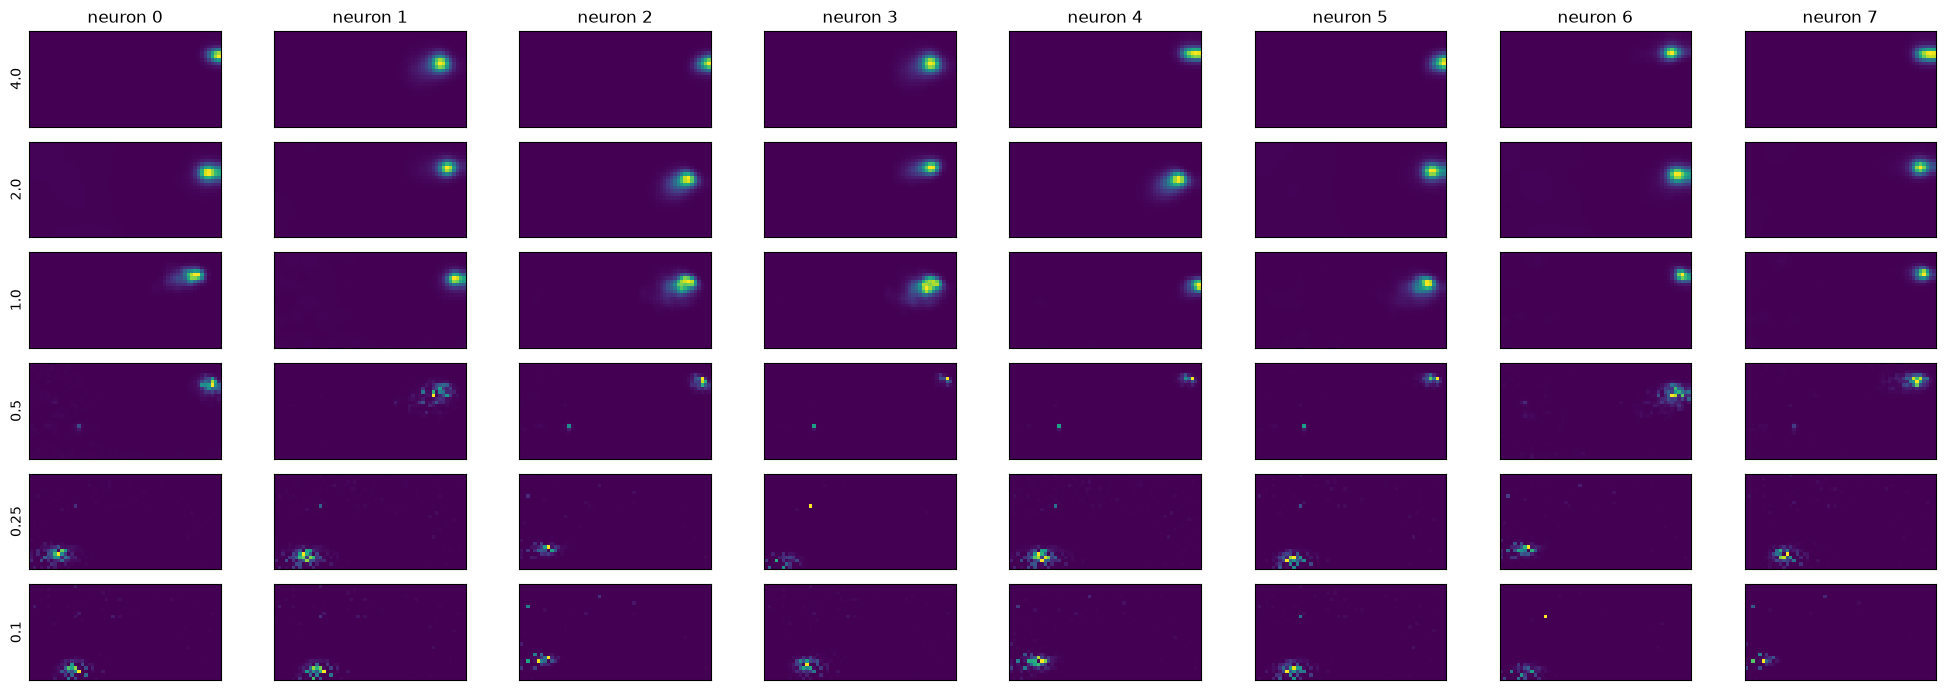

In [9]:
n = 8
fig, axs = plt.subplots(len(models), n, figsize=(20, 7))

for i, (sigma, model) in enumerate(models.items()):    
    spatials = torch.cat([model.readout[k].spatial.detach().cpu() for k in [data_keys[4]]])
    neurons = torch.randperm(spatials.shape[0])[:n]
    for j in range(n):
        ax = axs[i][j]
        ax.imshow(spatials[neurons[j]])
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f'neuron {j}')
        if j == 0:
            ax.set_ylabel(sigma)

plt.tight_layout()